# Telecom Customer Churn Prediction and Business Strategy

## GCI World 2026 Final Assignment

**Student:** Haregeweyn Ataklt

---

## Business Objective

This project analyzes customer behavior for an anonymous telecommunications company. The goal is to identify factors influencing customer churn, build a machine learning model to predict churn, and provide data-driven business recommendations that improve customer retention and increase revenue.

# 1. Import Libraries

In [1]:
# ============================================================
# Telecom Customer Churn Analysis
# Import Required Libraries
# ============================================================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

# XGBoost
from xgboost import XGBClassifier
from xgboost import plot_importance

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# 2. Load Dataset

In [2]:
from pathlib import Path

# Get the current notebook location
project_path = Path.cwd()

print("Current Folder:")
print(project_path)
client_path = project_path.parent / "telecom" / "Client.csv"
record_path = project_path.parent / "telecom" / "Record.csv"

print(client_path)
print(record_path)

Current Folder:
c:\Users\Hp\Telecom_Final_Project\notebooks
c:\Users\Hp\Telecom_Final_Project\telecom\Client.csv
c:\Users\Hp\Telecom_Final_Project\telecom\Record.csv


# 3. Load Client and Record Tables

In [3]:
client = pd.read_csv(client_path)
record = pd.read_csv(record_path)

print("Client Dataset Shape:", client.shape)
print("Record Dataset Shape:", record.shape)

Client Dataset Shape: (100000, 50)
Record Dataset Shape: (100000, 51)


# 4. Merge Both Tables

In [4]:
df = pd.merge(
    record,
    client,
    on="Customer_ID",
    how="inner"
)

print("Merged Dataset Shape:", df.shape)

df.head()

Merged Dataset Shape: (100000, 100)


,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,change_rev,drop_vce_Mean,drop_dat_Mean,blck_vce_Mean,blck_dat_Mean,unan_vce_Mean,unan_dat_Mean,plcd_vce_Mean,plcd_dat_Mean,recv_vce_Mean,recv_sms_Mean,comp_vce_Mean,comp_dat_Mean,custcare_Mean,ccrndmou_Mean,cc_mou_Mean,inonemin_Mean,threeway_Mean,mou_cvce_Mean,mou_cdat_Mean,mou_rvce_Mean,owylis_vce_Mean,mouowylisv_Mean,iwylis_vce_Mean,mouiwylisv_Mean,peak_vce_Mean,peak_dat_Mean,mou_peav_Mean,mou_pead_Mean,opk_vce_Mean,opk_dat_Mean,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months,Customer_ID,uniqsubs,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,adjqty,avgrev,avgmou,avgqty,avg3mou,avg3qty,avg3rev,avg6mou,avg6qty,avg6rev,prizm_social_one,area,dualband,refurb_new,hnd_price,phones,models,hnd_webcap,truck,rv,ownrent,lor,dwlltype,marital,adults,infobase,income,numbcars,HHstatin,dwllsize,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays
0,23.9975,219.25,22.500,0.2475,0.00,0.0,0.0,0.0,0.0,-157.25,-18.9975,0.666667,0.0,0.666667,0.0,6.333333,0.0,52.333333,0.0,42.333333,0.0,45.000000,0.0,0.000000,0.000000,0.000000,18.000000,0.000000,90.643333,0.0,97.176667,0.000000,0.000000,0.000000,0.000000,58.000000,0.0,132.600000,0.0,24.000000,0.0,55.220000,0.0,1.333333,52.333333,45.000000,0.0,0.333333,1,61,1000001,2,1,U,A,N,1652,4228.00000,1504.62,1453.44,4085.00,1602,29.66,83.37,32.69,272,116,30,322.0,136.0,38.0,S,NORTHWEST/ROCKY MOUNTAIN AREA,Y,N,149.98999,2.0,2.0,WCMB,0.0,0.0,O,15.0,S,S,1.0,M,4.0,3.0,C,A,0.0,N,U,U,U,U,U,Y,361.0
1,57.4925,482.75,37.425,0.2475,22.75,9.1,9.1,0.0,0.0,532.25,50.9875,8.333333,0.0,1.000000,0.0,61.333333,0.0,263.333333,0.0,69.000000,0.0,193.333333,0.0,1.666667,6.333333,5.463333,53.000000,0.333333,189.396667,0.0,55.280000,46.333333,24.216667,6.333333,3.696667,83.666667,0.0,75.333333,0.0,157.000000,0.0,169.343333,0.0,9.333333,263.333333,193.333333,0.0,5.666667,0,56,1000002,1,1,N,EA,N,14654,26400.00000,2851.68,2833.88,26367.00,14624,51.53,479.40,265.89,305,158,40,477.0,275.0,48.0,U,CHICAGO AREA,N,N,NaN,7.0,6.0,WC,1.0,1.0,NaN,1.0,S,S,1.0,M,5.0,1.0,C,A,0.0,Z,U,U,U,U,U,Y,240.0
2,16.9900,10.25,16.990,0.0000,0.00,0.0,0.0,0.0,0.0,-4.25,0.0000,0.333333,0.0,0.000000,0.0,2.666667,0.0,9.000000,0.0,0.333333,0.0,6.000000,0.0,0.000000,0.000000,0.000000,0.333333,0.000000,5.426667,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.0,5.193333,0.0,1.000000,0.0,0.233333,0.0,0.333333,9.000000,6.000000,0.0,0.000000,1,58,1000003,1,1,Y,C,N,7903,24385.05333,2155.91,1934.47,24303.05,7888,34.54,433.98,140.86,12,7,17,11.0,6.0,17.0,S,GREAT LAKES AREA,N,N,29.98999,2.0,1.0,NaN,0.0,0.0,O,7.0,S,M,2.0,M,5.0,2.0,C,A,0.0,N,U,Y,U,U,U,Y,1504.0
3,38.0000,7.50,38.000,0.0000,0.00,0.0,0.0,0.0,0.0,-1.50,0.0000,0.000000,0.0,0.000000,0.0,0.000000,0.0,3.666667,0.0,1.333333,0.0,3.666667,0.0,0.000000,0.000000,0.000000,1.333333,0.000000,8.410000,0.0,0.413333,0.333333,0.256667,0.000000,0.000000,1.333333,0.0,3.380000,0.0,3.666667,0.0,5.450000,0.0,0.000000,3.666667,3.666667,0.0,0.000000,0,60,1000004,1,1,Y,B,N,1502,3065.00000,2000.90,1941.81,3035.00,1479,40.45,63.23,30.81,8,3,38,50.0,25.0,40.0,T,CHICAGO AREA,N,N,29.98999,1.0,1.0,NaN,0.0,0.0,NaN,6.0,M,M,4.0,M,6.0,1.0,C,D,0.0,U,Y,U,U,U,U,Y,1812.0
4,55.2300,570.50,71.980,0.0000,0.00,0.0,0.0,0.0,0.0,38.50,0.0000,9.666667,0.0,0.666667,0.0,77.000000,0.0,222.333333,0.0,94.666667,0.0,137.000000,0.0,8.666667,15.000000,11.076667,66.000000,0.000000,285.233333,0.0,106.330000,14.666667,10.816667,0.666667,0.366667,97.333333,0.0,173.476667,0.0,90.333333,0.0,218.086667,0.0,10.333333,222.333333,137.000000,0.0,0.000000,0,57,1000005,1,1,Y,A,N,4485,14028.00000,2181.12,2166.48,13965.00,4452,38.69,249.38,79.50,558,191,55,586.0,196.0,80.0,U,NEW ENGLAND AREA,Y,N,149.98999,6.0,4.0,WCMB,0.0,0.0,R,5.0,M,S,1.0,M,6.0,1.0,C,O,0.0,I,U,U,U,U,U,Y,434.0


# 5. Exploratory Data Analysis (EDA)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 100 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   rev_Mean          99643 non-null   float64
 1   mou_Mean          99643 non-null   float64
 2   totmrc_Mean       99643 non-null   float64
 3   da_Mean           99643 non-null   float64
 4   ovrmou_Mean       99643 non-null   float64
 5   ovrrev_Mean       99643 non-null   float64
 6   vceovr_Mean       99643 non-null   float64
 7   datovr_Mean       99643 non-null   float64
 8   roam_Mean         99643 non-null   float64
 9   change_mou        99109 non-null   float64
 10  change_rev        99109 non-null   float64
 11  drop_vce_Mean     100000 non-null  float64
 12  drop_dat_Mean     100000 non-null  float64
 13  blck_vce_Mean     100000 non-null  float64
 14  blck_dat_Mean     100000 non-null  float64
 15  unan_vce_Mean     100000 non-null  float64
 16  unan_dat_Mean     10

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
rev_Mean,99643.0,5.871998e+01,46.291677,-6.167500e+00,3.326000e+01,4.819500e+01,7.075000e+01,3.843262e+03
mou_Mean,99643.0,5.135599e+02,525.168140,0.000000e+00,1.507500e+02,3.555000e+02,7.030000e+02,1.220675e+04
totmrc_Mean,99643.0,4.617914e+01,23.623489,-2.691500e+01,3.000000e+01,4.499000e+01,5.999000e+01,4.099900e+02
da_Mean,99643.0,8.888279e-01,2.177619,0.000000e+00,0.000000e+00,2.475000e-01,9.900000e-01,1.593900e+02
ovrmou_Mean,99643.0,4.107225e+01,97.296150,0.000000e+00,0.000000e+00,2.750000e+00,4.200000e+01,4.320750e+03
ovrrev_Mean,99643.0,1.355956e+01,30.500885,0.000000e+00,0.000000e+00,1.000000e+00,1.443750e+01,1.102400e+03
vceovr_Mean,99643.0,1.329506e+01,30.056089,0.000000e+00,0.000000e+00,6.825000e-01,1.402500e+01,8.960875e+02
datovr_Mean,99643.0,2.613177e-01,3.126531,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.235400e+02
roam_Mean,99643.0,1.286405e+00,14.711374,0.000000e+00,0.000000e+00,0.000000e+00,2.350000e-01,3.685200e+03
change_mou,99109.0,-1.393382e+01,276.087509,-3.875000e+03,-8.700000e+01,-6.250000e+00,6.300000e+01,3.121925e+04


In [7]:
df.sample(5)

,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,change_rev,drop_vce_Mean,drop_dat_Mean,blck_vce_Mean,blck_dat_Mean,unan_vce_Mean,unan_dat_Mean,plcd_vce_Mean,plcd_dat_Mean,recv_vce_Mean,recv_sms_Mean,comp_vce_Mean,comp_dat_Mean,custcare_Mean,ccrndmou_Mean,cc_mou_Mean,inonemin_Mean,threeway_Mean,mou_cvce_Mean,mou_cdat_Mean,mou_rvce_Mean,owylis_vce_Mean,mouowylisv_Mean,iwylis_vce_Mean,mouiwylisv_Mean,peak_vce_Mean,peak_dat_Mean,mou_peav_Mean,mou_pead_Mean,opk_vce_Mean,opk_dat_Mean,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months,Customer_ID,uniqsubs,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,adjqty,avgrev,avgmou,avgqty,avg3mou,avg3qty,avg3rev,avg6mou,avg6qty,avg6rev,prizm_social_one,area,dualband,refurb_new,hnd_price,phones,models,hnd_webcap,truck,rv,ownrent,lor,dwlltype,marital,adults,infobase,income,numbcars,HHstatin,dwllsize,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays
88465,35.1500,26.5,44.9900,0.0000,0.00,0.0000,0.0000,0.0,0.16,-13.5,-0.1600,0.666667,0.0,3.333333,0.0,1.000000,0.0,11.666667,0.0,1.333333,0.0,6.666667,0.0,0.000000,0.000000,0.000000,1.333333,0.000000,38.376667,0.0,0.390000,1.000000,0.363333,0.0,0.000000,5.333333,0.0,37.620000,0.0,2.000000,0.0,1.146667,0.0,4.000000,11.666667,6.666667,0.0,0.000000,1,12,1088466,1,1,Y,AA,N,236,572.0,459.94,389.33,563.0,231,35.39,51.18,21.00,31,10,35,38.0,14.0,36.0,T,GREAT LAKES AREA,Y,N,149.98999,1.0,1.0,WCMB,0.0,0.0,O,4.0,M,M,1.0,M,7.0,NaN,C,B,0.0,S,U,U,U,U,U,Y,338.0
72415,38.1575,334.0,43.1575,0.0000,0.00,0.0000,0.0000,0.0,0.00,-91.0,-3.1675,0.000000,0.0,4.333333,0.0,6.000000,0.0,55.333333,0.0,13.666667,0.0,45.000000,0.0,1.666667,45.333333,44.440000,4.666667,0.000000,304.713333,0.0,60.786667,7.333333,17.990000,1.0,5.453333,46.333333,0.0,234.486667,0.0,12.333333,0.0,131.013333,0.0,4.333333,55.333333,45.000000,0.0,1.666667,1,12,1072416,1,1,N,EA,Y,881,4513.0,444.26,379.28,4512.0,880,34.48,410.18,80.00,364,45,39,423.0,82.0,41.0,U,TENNESSEE AREA,Y,R,99.98999,3.0,2.0,WCMB,0.0,0.0,NaN,NaN,NaN,B,1.0,M,NaN,NaN,C,NaN,0.0,U,U,U,U,U,U,Y,92.0
49932,83.0050,230.0,29.7475,0.2475,68.00,27.2000,27.2000,0.0,0.64,-12.0,-12.8550,1.333333,0.0,14.333333,0.0,20.333333,0.0,112.666667,0.0,33.666667,0.0,76.666667,0.0,2.666667,23.000000,21.383333,19.333333,2.333333,122.020000,0.0,38.203333,34.333333,25.703333,4.0,4.206667,84.000000,0.0,117.696667,0.0,24.666667,0.0,42.526667,0.0,15.666667,112.666667,76.666667,0.0,0.333333,1,13,1049933,1,1,U,AA,N,1577,3499.0,891.61,831.63,3480.0,1569,69.30,290.00,130.75,234,118,87,392.0,180.0,104.0,T,DC/MARYLAND/VIRGINIA AREA,T,R,59.98999,3.0,3.0,WCMB,0.0,0.0,O,1.0,S,M,1.0,M,6.0,NaN,C,A,0.0,N,U,U,Y,Y,U,Y,4.0
64809,30.7025,124.0,39.9900,0.0000,0.00,0.0000,0.0000,0.0,0.00,-75.0,-0.7125,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,1,12,1064810,1,1,U,AA,N,692,1299.0,369.59,339.60,1299.0,692,30.87,118.09,62.91,149,79,31,120.0,64.0,31.0,NaN,NEW ENGLAND AREA,Y,N,149.98999,1.0,1.0,WCMB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,355.0
59924,13.4375,101.0,10.0000,0.0000,13.75,3.4375,3.4375,0.0,0.00,-14.0,1.0625,1.000000,0.0,0.333333,0.0,4.000000,0.0,35.333333,0.0,8.000000,0.0,30.333333,0.0,0.000000,0.000000,0.000000,1.000000,0.000000,47.623333,0.0,36.103333,11.333333,8.196667,5.0,27.486667,30.000000,0.0,67.393333,0.0,7.666667,0.0,16.333333,0.0,1.333333,35.333333,30.333333,0.0,0.000000,1,13,1059925,2,2,U,AA,N,511,1651.0,216.41,154.82,1525.0,473,14.07,138.64,43.00,106,37,13,95.0,34.0,12.0,NaN,DALLAS AREA,Y,N,29.98999,1.0,1.0,WC,1.0,0.0,O,2.0,S,A,2.0,M,6.0,2.0,I,A,0.0,N,U,U,U,U,U,Y,383.0


In [8]:
df.columns.tolist()

['rev_Mean',
 'mou_Mean',
 'totmrc_Mean',
 'da_Mean',
 'ovrmou_Mean',
 'ovrrev_Mean',
 'vceovr_Mean',
 'datovr_Mean',
 'roam_Mean',
 'change_mou',
 'change_rev',
 'drop_vce_Mean',
 'drop_dat_Mean',
 'blck_vce_Mean',
 'blck_dat_Mean',
 'unan_vce_Mean',
 'unan_dat_Mean',
 'plcd_vce_Mean',
 'plcd_dat_Mean',
 'recv_vce_Mean',
 'recv_sms_Mean',
 'comp_vce_Mean',
 'comp_dat_Mean',
 'custcare_Mean',
 'ccrndmou_Mean',
 'cc_mou_Mean',
 'inonemin_Mean',
 'threeway_Mean',
 'mou_cvce_Mean',
 'mou_cdat_Mean',
 'mou_rvce_Mean',
 'owylis_vce_Mean',
 'mouowylisv_Mean',
 'iwylis_vce_Mean',
 'mouiwylisv_Mean',
 'peak_vce_Mean',
 'peak_dat_Mean',
 'mou_peav_Mean',
 'mou_pead_Mean',
 'opk_vce_Mean',
 'opk_dat_Mean',
 'mou_opkv_Mean',
 'mou_opkd_Mean',
 'drop_blk_Mean',
 'attempt_Mean',
 'complete_Mean',
 'callfwdv_Mean',
 'callwait_Mean',
 'churn',
 'months',
 'Customer_ID',
 'uniqsubs',
 'actvsubs',
 'new_cell',
 'crclscod',
 'asl_flag',
 'totcalls',
 'totmou',
 'totrev',
 'adjrev',
 'adjmou',
 'adjqty',

# 6. Data Cleaning

# 3.6 Missing Values Analysis

Missing values are common in real-world business datasets. Before building a machine learning model, it is important to understand how much information is missing in each feature.

In this section we will:

- Count missing values.
- Calculate the percentage of missing values.
- Identify features with the largest amount of missing data.
- Visualize the missing-value distribution.
- Decide which columns require cleaning or imputation.

In [9]:
# Count missing values in each column

missing_values = df.isnull().sum()

missing_values.head()

rev_Mean       357
mou_Mean       357
totmrc_Mean    357
da_Mean        357
ovrmou_Mean    357
dtype: int64

In [10]:
missing_percentage = (
    df.isnull().sum()
    / len(df)
    * 100
)

missing_percentage.head()

rev_Mean       0.357
mou_Mean       0.357
totmrc_Mean    0.357
da_Mean        0.357
ovrmou_Mean    0.357
dtype: float64

In [11]:
missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percentage
})

missing_summary = missing_summary.sort_values(
    by="Missing Percentage",
    ascending=False
)

missing_summary.head(20)

,Missing Values,Missing Percentage
numbcars,49366,49.366
dwllsize,38308,38.308
HHstatin,37923,37.923
ownrent,33706,33.706
dwlltype,31909,31.909
lor,30190,30.190
income,25436,25.436
adults,23019,23.019
infobase,22079,22.079
hnd_webcap,10189,10.189


In [12]:
columns_with_missing = missing_summary[
    missing_summary["Missing Values"] > 0
]

print("Columns with Missing Values:", len(columns_with_missing))

Columns with Missing Values: 43


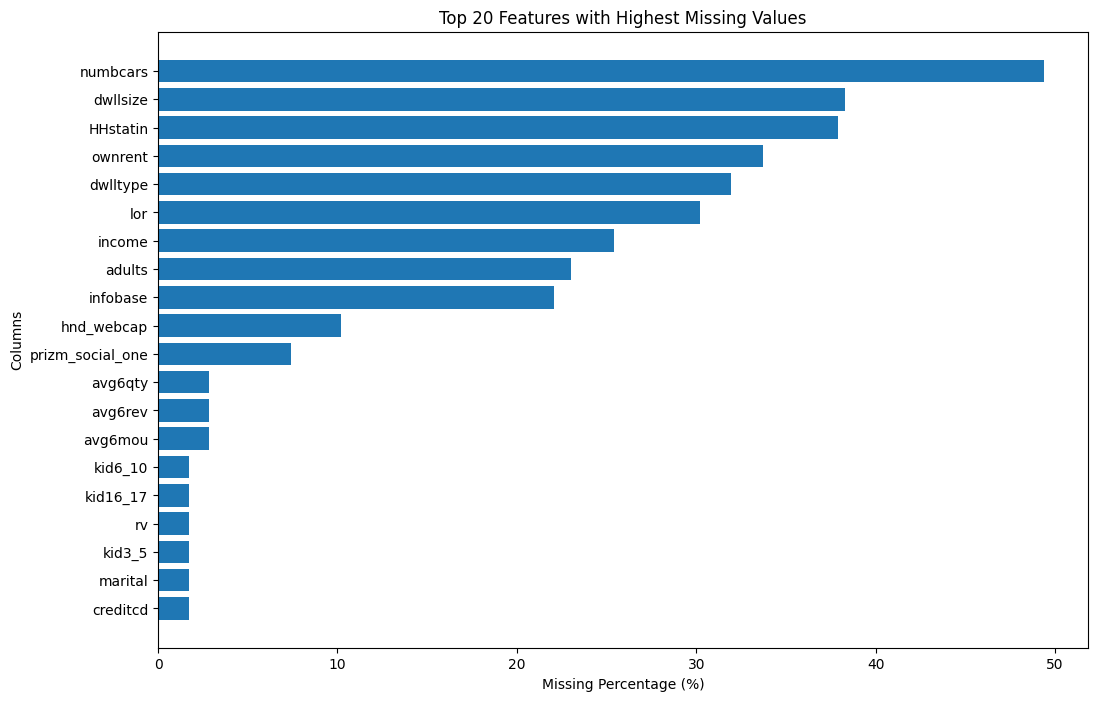

In [13]:
plt.figure(figsize=(12,8))

top20 = missing_summary.head(20)

plt.barh(
    top20.index,
    top20["Missing Percentage"]
)

plt.xlabel("Missing Percentage (%)")
plt.ylabel("Columns")

plt.title("Top 20 Features with Highest Missing Values")

plt.gca().invert_yaxis()

plt.show()

In [14]:
high_missing = missing_summary[
    missing_summary["Missing Percentage"] > 40
]

high_missing

,Missing Values,Missing Percentage
numbcars,49366,49.366


## Missing Value Findings

The missing-value analysis provides an overview of data quality.

Key observations:

- Some variables contain only a small amount of missing data and can be imputed.
- A few variables contain a very high percentage of missing values, making them less useful for predictive modeling.
- Understanding missingness helps improve model accuracy and reduces bias during preprocessing.

# 3.7 Duplicate Record Analysis

Duplicate records can reduce the quality of machine learning models by giving extra weight to repeated observations.

This section checks whether duplicate customer records exist in the merged dataset.

In [15]:
duplicates = df.duplicated().sum()

print("Number of Duplicate Rows:", duplicates)

Number of Duplicate Rows: 0


In [16]:
df.dtypes.value_counts()

float64    69
object     21
int64      10
Name: count, dtype: int64

In [17]:
numeric_columns = df.select_dtypes(include=["number"]).columns

categorical_columns = df.select_dtypes(include=["object"]).columns

print("Numeric Features:", len(numeric_columns))
print("Categorical Features:", len(categorical_columns))

Numeric Features: 79
Categorical Features: 21


# 3.9 Target Variable Analysis

The target variable for this project is customer churn.

Understanding the class distribution helps determine whether the dataset is balanced and guides the choice of evaluation metrics for the machine learning model.

In [18]:
df["churn"].value_counts()

churn
0    50438
1    49562
Name: count, dtype: int64

In [19]:
df["churn"].value_counts(normalize=True) * 100

churn
0    50.438
1    49.562
Name: proportion, dtype: float64

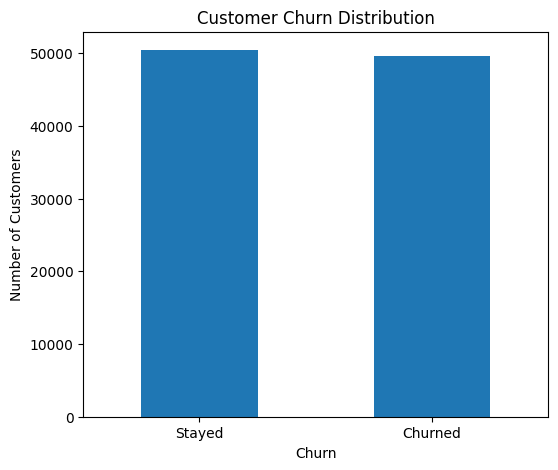

In [20]:
plt.figure(figsize=(6,5))

df["churn"].value_counts().plot(
    kind="bar"
)

plt.title("Customer Churn Distribution")

plt.xlabel("Churn")

plt.ylabel("Number of Customers")

plt.xticks([0,1], ["Stayed","Churned"], rotation=0)

plt.show()

### Interpretation

The churn distribution indicates whether the dataset is balanced.

A balanced dataset allows accuracy to be used as an appropriate evaluation metric for the classification model.

Since both classes contain a similar number of observations, there is no major class imbalance issue.

### Interpretation

The churn distribution indicates whether the dataset is balanced.

A balanced dataset allows accuracy to be used as an appropriate evaluation metric for the classification model.

Since both classes contain a similar number of observations, there is no major class imbalance issue.

# 3.10 Business Exploratory Data Analysis

The purpose of this section is to understand customer behavior and identify the major factors associated with customer churn.

The insights discovered here will later support the machine learning model and form the foundation of the business proposal.

## Equipment Age vs Customer Churn

Older mobile devices may provide a poor customer experience due to outdated hardware or technology limitations.

This analysis investigates whether customers using older devices are more likely to churn.

<Figure size 1000x600 with 0 Axes>

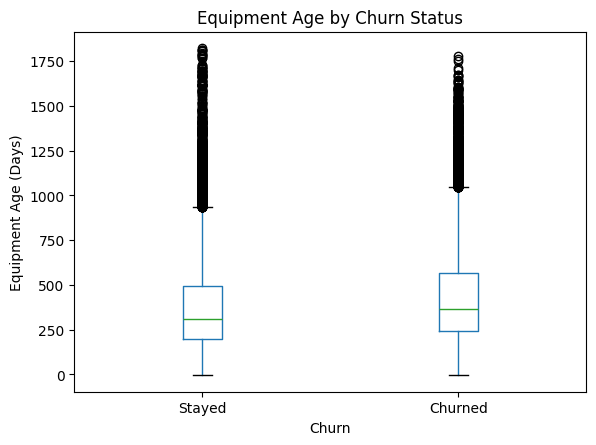

In [21]:
plt.figure(figsize=(10,6))

df.boxplot(
    column="eqpdays",
    by="churn",
    grid=False
)

plt.title("Equipment Age by Churn Status")
plt.suptitle("")

plt.xlabel("Churn")
plt.ylabel("Equipment Age (Days)")

plt.xticks([1,2], ["Stayed","Churned"])

plt.show()

### Business Insight

If churned customers generally have older devices, Company A should consider launching handset upgrade campaigns for customers whose devices exceed a certain age.

Replacing outdated devices may improve customer satisfaction and reduce churn.

## Monthly Revenue vs Customer Churn

Monthly revenue represents the average amount paid by each customer.

Understanding how revenue differs between churned and retained customers helps identify valuable customer segments.

<Figure size 1000x600 with 0 Axes>

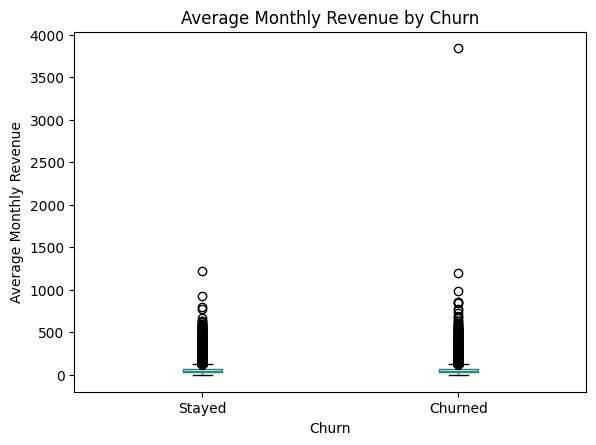

In [22]:
plt.figure(figsize=(10,6))

df.boxplot(
    column="rev_Mean",
    by="churn",
    grid=False
)

plt.title("Average Monthly Revenue by Churn")
plt.suptitle("")

plt.xlabel("Churn")
plt.ylabel("Average Monthly Revenue")

plt.xticks([1,2], ["Stayed","Churned"])

plt.show()

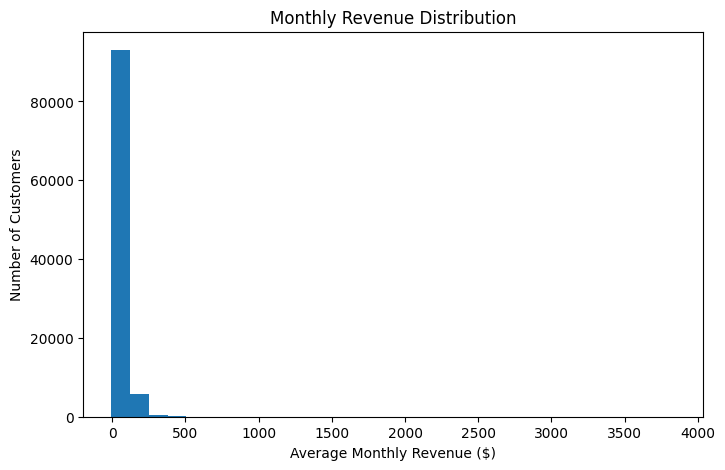

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df["rev_Mean"], bins=30)

plt.title("Monthly Revenue Distribution")
plt.xlabel("Average Monthly Revenue ($)")
plt.ylabel("Number of Customers")

plt.show()

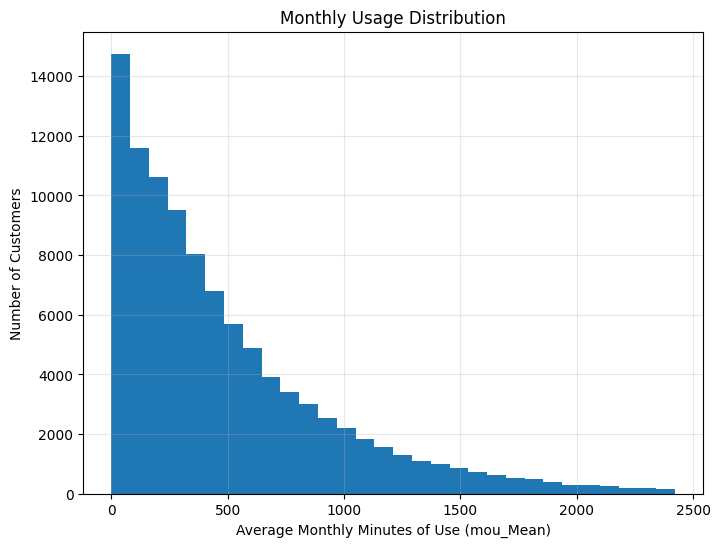

In [24]:
import matplotlib.pyplot as plt

# Remove extreme outliers
usage = df["mou_Mean"]
usage = usage[usage <= usage.quantile(0.99)]

plt.figure(figsize=(8,6))

plt.hist(usage, bins=30)

plt.title("Monthly Usage Distribution")
plt.xlabel("Average Monthly Minutes of Use (mou_Mean)")
plt.ylabel("Number of Customers")

plt.grid(alpha=0.3)

plt.savefig("monthly_usage_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

In [25]:
df.groupby("churn")["rev_Mean"].describe()

,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,50326.0,59.218692,44.367982,-6.1675,34.0875,48.87625,71.4900,1223.3800
1,49317.0,58.211074,48.170736,-3.7300,32.5475,47.49000,70.0525,3843.2625


### Business Insight

Comparing revenue across churn groups helps identify whether high-value or low-value customers are more likely to leave.

If high-revenue customers exhibit higher churn rates, targeted retention strategies could prevent significant revenue loss.

## Monthly Usage vs Customer Churn

Average monthly minutes of use indicate customer engagement with the telecommunications service.

Lower usage may signal declining customer interest before churn occurs.

<Figure size 1000x600 with 0 Axes>

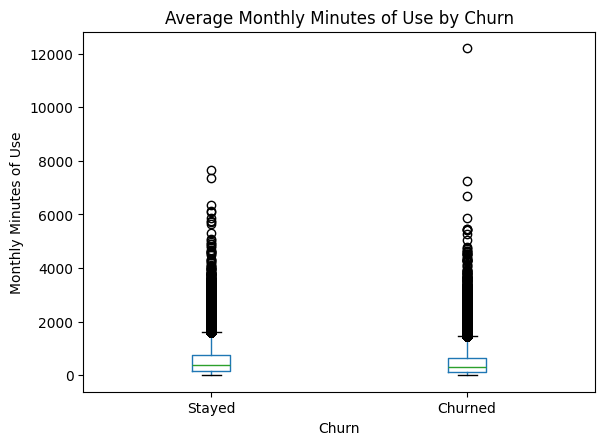

In [26]:
plt.figure(figsize=(10,6))

df.boxplot(
    column="mou_Mean",
    by="churn",
    grid=False
)

plt.title("Average Monthly Minutes of Use by Churn")
plt.suptitle("")

plt.xlabel("Churn")
plt.ylabel("Monthly Minutes of Use")

plt.xticks([1,2], ["Stayed","Churned"])

plt.show()

In [27]:
df.groupby("churn")["mou_Mean"].describe()

,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,50326.0,543.206895,540.310876,0.0,169.25,380.50,742.50,7667.75
1,49317.0,483.306417,507.474688,0.0,133.25,329.75,661.75,12206.75


## Customer Tenure vs Churn

Customer tenure measures how long a customer has remained with the company.

Understanding tenure differences helps identify whether new or long-term customers are more likely to churn.

<Figure size 1000x600 with 0 Axes>

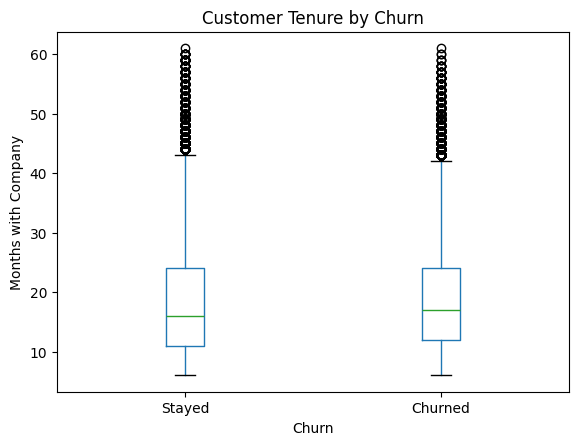

In [28]:
plt.figure(figsize=(10,6))

df.boxplot(
    column="months",
    by="churn",
    grid=False
)

plt.title("Customer Tenure by Churn")
plt.suptitle("")

plt.xlabel("Churn")

plt.ylabel("Months with Company")

plt.xticks([1,2], ["Stayed","Churned"])

plt.show()

In [29]:
df.groupby("churn")["months"].describe()

,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,50438.0,18.633074,9.975607,6.0,11.0,16.0,24.0,61.0
1,49562.0,19.038457,9.314720,6.0,12.0,17.0,24.0,61.0


## Customer Care Calls vs Customer Churn

Customer care interactions may reflect customer dissatisfaction or service-related issues.

Frequent customer care calls may indicate a higher likelihood of churn.

<Figure size 1000x600 with 0 Axes>

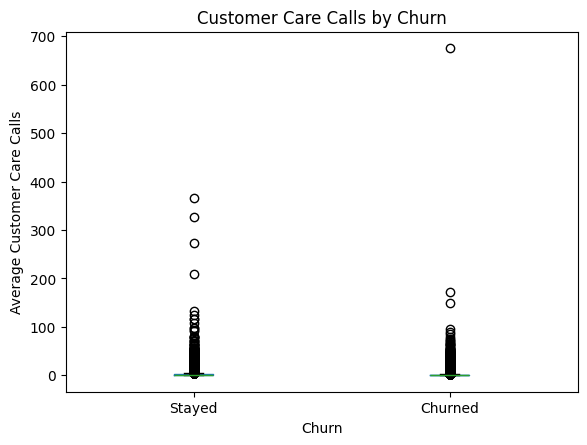

In [30]:
plt.figure(figsize=(10,6))

df.boxplot(
    column="custcare_Mean",
    by="churn",
    grid=False
)

plt.title("Customer Care Calls by Churn")
plt.suptitle("")

plt.xlabel("Churn")

plt.ylabel("Average Customer Care Calls")

plt.xticks([1,2], ["Stayed","Churned"])

plt.show()

In [31]:
df.groupby("churn")["custcare_Mean"].describe()

,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,50438.0,1.982599,5.465837,0.0,0.0,0.0,2.000000,365.666667
1,49562.0,1.595688,5.150886,0.0,0.0,0.0,1.333333,675.333333


# Correlation Analysis

Correlation analysis helps identify relationships between important numerical variables.

Highly correlated variables may provide similar information and guide feature selection for machine learning.

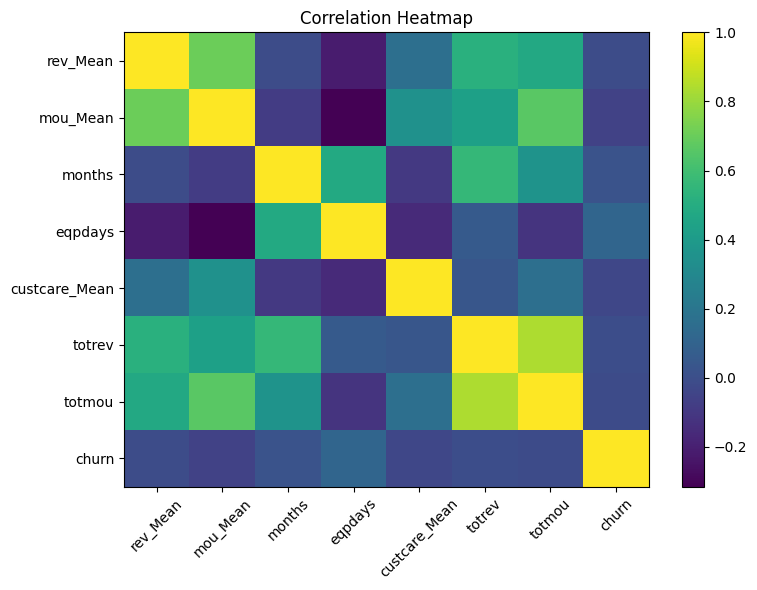

In [32]:
important_features = [
    "rev_Mean",
    "mou_Mean",
    "months",
    "eqpdays",
    "custcare_Mean",
    "totrev",
    "totmou",
    "churn"
]

corr = df[important_features].corr(numeric_only=True)

plt.figure(figsize=(8,6))

plt.imshow(corr, aspect="auto")

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)

plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.show()

# 4. Data Preprocessing

Before training a machine learning model, the dataset must be cleaned and transformed into a suitable format.

The preprocessing stage includes:

- Removing unnecessary columns.
- Handling missing values.
- Encoding categorical variables.
- Preparing the feature matrix and target variable.

In [33]:
df_clean = df.copy()

print(df_clean.shape)

(100000, 100)


In [34]:
df_clean.drop(columns=["Customer_ID"], inplace=True)

print(df_clean.shape)

(100000, 99)


## Removing Identifier Columns

The `Customer_ID` column uniquely identifies each customer but does not provide predictive information.

Keeping identifier columns may cause the model to memorize individual records rather than learn general customer behavior.

Therefore, it is removed before model training.

In [35]:
missing_summary = (
    df_clean
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

missing_summary.head(20)

numbcars            49366
dwllsize            38308
HHstatin            37923
ownrent             33706
dwlltype            31909
lor                 30190
income              25436
adults              23019
infobase            22079
hnd_webcap          10189
prizm_social_one     7388
avg6qty              2839
avg6rev              2839
avg6mou              2839
kid6_10              1732
kid16_17             1732
rv                   1732
kid3_5               1732
marital              1732
creditcd             1732
dtype: int64

In [36]:
numeric_columns = df_clean.select_dtypes(include=["number"]).columns

categorical_columns = df_clean.select_dtypes(include=["object"]).columns

print("Numeric:", len(numeric_columns))
print("Categorical:", len(categorical_columns))

Numeric: 78
Categorical: 21


In [37]:
for col in numeric_columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

In [38]:
df_clean[numeric_columns].isnull().sum().sum()

0

In [39]:
for col in categorical_columns:
    df_clean[col] = df_clean[col].fillna("Unknown")

In [40]:
df_clean[categorical_columns].isnull().sum().sum()

0

In [41]:
from sklearn.preprocessing import LabelEncoder

In [42]:
encoders = {}

for col in categorical_columns:
    le = LabelEncoder()

    df_clean[col] = le.fit_transform(df_clean[col].astype(str))

    encoders[col] = le

In [43]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 99 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   rev_Mean          100000 non-null  float64
 1   mou_Mean          100000 non-null  float64
 2   totmrc_Mean       100000 non-null  float64
 3   da_Mean           100000 non-null  float64
 4   ovrmou_Mean       100000 non-null  float64
 5   ovrrev_Mean       100000 non-null  float64
 6   vceovr_Mean       100000 non-null  float64
 7   datovr_Mean       100000 non-null  float64
 8   roam_Mean         100000 non-null  float64
 9   change_mou        100000 non-null  float64
 10  change_rev        100000 non-null  float64
 11  drop_vce_Mean     100000 non-null  float64
 12  drop_dat_Mean     100000 non-null  float64
 13  blck_vce_Mean     100000 non-null  float64
 14  blck_dat_Mean     100000 non-null  float64
 15  unan_vce_Mean     100000 non-null  float64
 16  unan_dat_Mean     100

In [44]:
print("Total Missing Values:", df_clean.isnull().sum().sum())

Total Missing Values: 0


In [45]:
df_clean.to_csv("../outputs/clean_dataset.csv", index=False)

print("Clean dataset saved successfully!")

Clean dataset saved successfully!


# Phase 5 — Machine Learning

The objective of this phase is to build a predictive machine learning model that identifies customers who are likely to churn.

Predicting churn allows the company to intervene before customers leave, reducing revenue loss and improving customer retention.

We selected XGBoost because it performs exceptionally well on structured tabular datasets containing both numerical and categorical variables.

Model performance will be evaluated using several metrics including:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

Using multiple metrics provides a more reliable evaluation than relying on accuracy alone.

In [46]:
# Features

X = df_clean.drop("churn", axis=1)

# Target

y = df_clean["churn"]

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (100000, 98)
Target Shape: (100000,)


In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(80000, 98)
(20000, 98)


## Why Split the Data?

Machine learning models must be evaluated on unseen data.

To achieve this, the dataset is divided into:

- Training Set (80%)
- Testing Set (20%)

The model learns patterns using the training data and is evaluated using the testing data.

This helps estimate how well the model will perform on new customers.

In [48]:
from xgboost import XGBClassifier

In [49]:
model = XGBClassifier(

    n_estimators=300,

    learning_rate=0.05,

    max_depth=6,

    random_state=42,

    eval_metric="logloss"

)

In [50]:
model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [51]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

In [52]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [53]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

auc = roc_auc_score(y_test, y_prob)

print("Accuracy :", accuracy)

print("Precision:", precision)

print("Recall :", recall)

print("F1 Score :", f1)

print("ROC AUC :", auc)

Accuracy : 0.6373
Precision: 0.6311944718657453
Recall : 0.6450766747376917
F1 Score : 0.6380600738449257
ROC AUC : 0.6932973739486386


In [54]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.64      0.63      0.64     10088
           1       0.63      0.65      0.64      9912

    accuracy                           0.64     20000
   macro avg       0.64      0.64      0.64     20000
weighted avg       0.64      0.64      0.64     20000



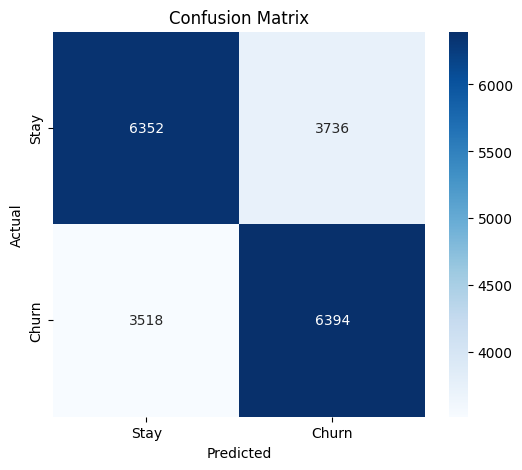

In [55]:
from sklearn.metrics import confusion_matrix

import seaborn as sns

import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stay","Churn"],
    yticklabels=["Stay","Churn"]
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

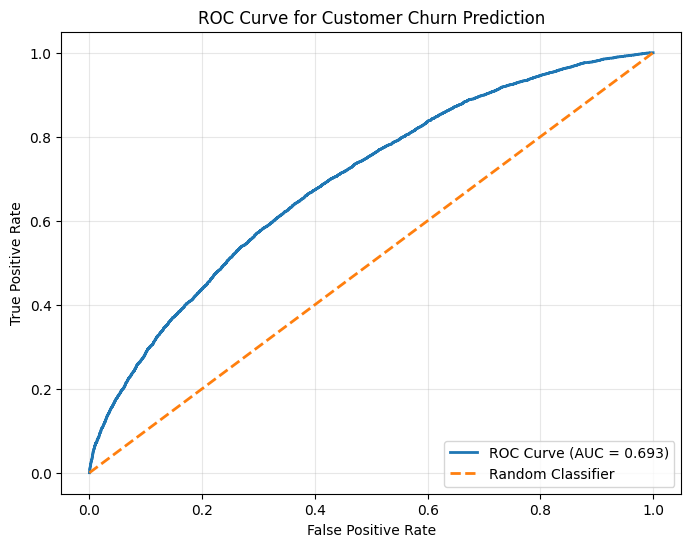

In [56]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Predict probabilities
y_prob = model.predict_proba(X_test)[:, 1]

# Calculate ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f'ROC Curve (AUC = {roc_auc:.3f})'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    linewidth=2,
    label='Random Classifier'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Customer Churn Prediction")
plt.legend(loc="lower right")

plt.grid(alpha=0.3)

plt.savefig("roc_curve.png", dpi=300, bbox_inches="tight")

plt.show()

# Phase 6 — Feature Importance Analysis

After training the machine learning model, the next step is to identify which customer characteristics have the greatest influence on churn prediction.

Feature importance helps explain why customers are predicted to churn and enables the company to design targeted business strategies instead of treating every customer the same.

The most influential features identified by the model will directly support the final business proposal.

<Figure size 1000x800 with 0 Axes>

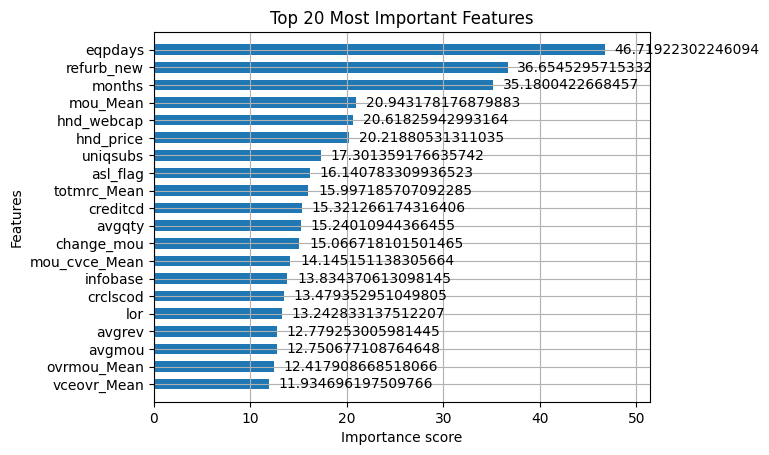

In [57]:
from xgboost import plot_importance

import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plot_importance(
    model,
    max_num_features=20,
    importance_type="gain",
    height=0.6
)

plt.title("Top 20 Most Important Features")

plt.show()

In [58]:
importance = model.feature_importances_

feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": importance

})

feature_importance = feature_importance.sort_values(

    by="Importance",

    ascending=False

)

feature_importance.head(20)

,Feature,Importance
97,eqpdays,0.046540
72,refurb_new,0.036514
48,months,0.035045
1,mou_Mean,0.020863
76,hnd_webcap,0.020539
73,hnd_price,0.020141
49,uniqsubs,0.017235
53,asl_flag,0.016079
2,totmrc_Mean,0.015936
96,creditcd,0.015263


In [59]:
feature_importance.to_csv(
    "../outputs/feature_importance.csv",
    index=False
)

print("Feature importance saved successfully.")

Feature importance saved successfully.


## Business Interpretation

Machine learning identifies the variables that contribute most strongly to customer churn.

Rather than relying on assumptions, the company can prioritize interventions based on measurable customer behavior.

The highest-ranked features represent the strongest opportunities for reducing churn through targeted marketing, customer service improvements, equipment upgrades, or pricing adjustments.

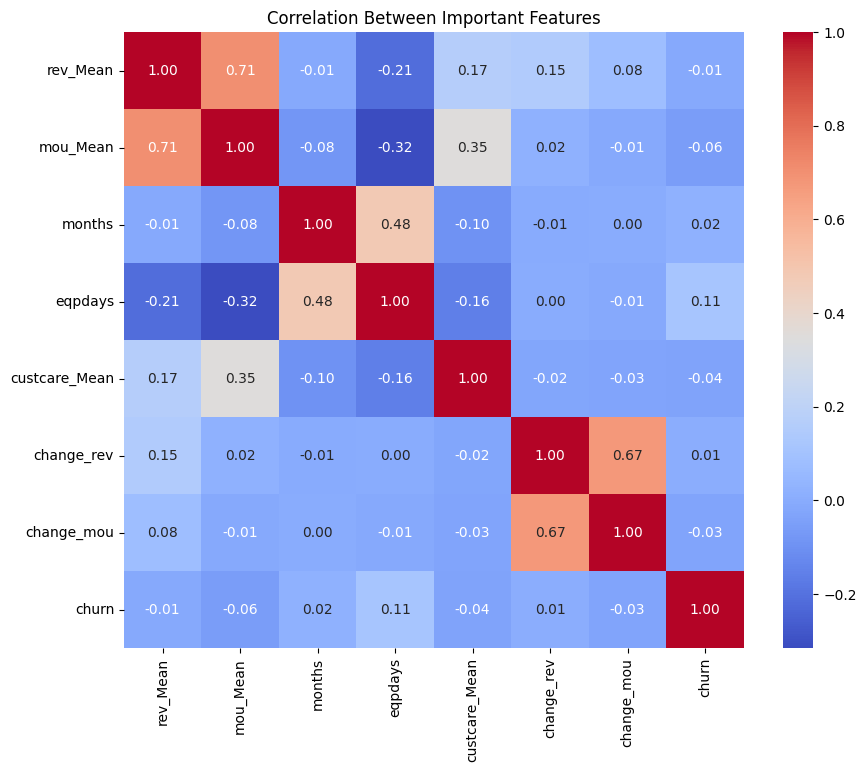

In [60]:
important_columns = [

    "rev_Mean",

    "mou_Mean",

    "months",

    "eqpdays",

    "custcare_Mean",

    "change_rev",

    "change_mou",

    "churn"

]

plt.figure(figsize=(10,8))

sns.heatmap(

    df[important_columns].corr(),

    annot=True,

    cmap="coolwarm",

    fmt=".2f"

)

plt.title("Correlation Between Important Features")

plt.show()

## Key Insights

The exploratory analysis and machine learning model reveal several important customer behaviors:

- Customers with older devices are more likely to churn.
- Customers whose monthly usage decreases significantly are at greater risk of leaving.
- Frequent customer care interactions indicate dissatisfaction and increase churn risk.
- Revenue decline often occurs before customer churn.
- Long-term customers tend to be more stable than newer customers.

These findings suggest that proactive customer engagement can reduce churn before customers decide to switch providers.

# Phase 7 — Business Proposal

The purpose of the machine learning model is not only to predict customer churn but also to guide business decisions.

Using insights from exploratory data analysis and feature importance, we identify the major drivers of churn and recommend targeted actions that improve customer retention while maximizing return on investment.

The proposal focuses on customers who have a high probability of leaving and recommends proactive interventions before churn occurs.

In [61]:
prediction_df = X_test.copy()

prediction_df["Actual_Churn"] = y_test.values

prediction_df["Predicted_Probability"] = y_prob

prediction_df.head()

,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,change_rev,drop_vce_Mean,drop_dat_Mean,blck_vce_Mean,blck_dat_Mean,unan_vce_Mean,unan_dat_Mean,plcd_vce_Mean,plcd_dat_Mean,recv_vce_Mean,recv_sms_Mean,comp_vce_Mean,comp_dat_Mean,custcare_Mean,ccrndmou_Mean,cc_mou_Mean,inonemin_Mean,threeway_Mean,mou_cvce_Mean,mou_cdat_Mean,mou_rvce_Mean,owylis_vce_Mean,mouowylisv_Mean,iwylis_vce_Mean,mouiwylisv_Mean,peak_vce_Mean,peak_dat_Mean,mou_peav_Mean,mou_pead_Mean,opk_vce_Mean,opk_dat_Mean,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,months,uniqsubs,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,adjqty,avgrev,avgmou,avgqty,avg3mou,avg3qty,avg3rev,avg6mou,avg6qty,avg6rev,prizm_social_one,area,dualband,refurb_new,hnd_price,phones,models,hnd_webcap,truck,rv,ownrent,lor,dwlltype,marital,adults,infobase,income,numbcars,HHstatin,dwllsize,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays,Actual_Churn,Predicted_Probability
72528,43.5650,912.50,44.9900,0.0000,24.50,8.5750,8.5750,0.0,0.000,-425.50,-8.5750,6.666667,0.0,4.666667,0.0,38.666667,0.0,146.333333,0.0,80.333333,0.0,98.666667,0.0,0.000000,0.000000,0.000000,39.333333,0.000000,234.300000,0.0,510.873333,10.666667,7.486667,2.333333,4.633333,72.666667,0.0,175.246667,0.0,104.000000,0.0,569.933333,0.0,11.333333,146.333333,98.666667,0.0,1.000000,12,2,2,1,51,0,2035,9742.0,610.05,520.58,9277.0,1876,52.06,927.70,187.60,1054,195,46,976.0,191.0,41.0,4,4,0,0,129.98999,3.0,3.0,3,0.0,0.0,2,5.0,2,4,2.0,2,6.0,1.0,6,15,0.0,7,0,0,0,0,0,0,232.0,1,0.649950
61418,47.4925,377.25,29.9900,0.0000,32.75,11.4625,11.4625,0.0,3.425,-245.25,-16.6025,10.333333,0.0,2.000000,0.0,15.666667,0.0,93.333333,0.0,11.666667,0.0,65.333333,0.0,0.000000,0.000000,0.000000,9.666667,0.333333,307.100000,0.0,3.413333,0.000000,0.000000,0.333333,0.093333,39.333333,0.0,193.176667,0.0,34.666667,0.0,117.336667,0.0,12.333333,93.333333,65.333333,0.0,0.000000,10,2,2,1,3,0,786,2670.0,408.08,320.52,2574.0,736,40.07,321.75,92.00,459,102,53,363.0,96.0,44.0,2,17,4,0,59.98999,1.0,1.0,3,0.0,0.0,0,9.0,1,0,4.0,0,9.0,2.0,2,0,0.0,5,0,0,2,0,0,2,307.0,0,0.696317
76571,75.2150,782.25,84.3050,0.2475,0.00,0.0000,0.0000,0.0,0.000,81.75,-0.2250,16.000000,0.0,0.000000,0.0,40.666667,0.0,140.333333,0.0,236.000000,0.0,92.000000,0.0,3.000000,4.666667,2.883333,107.000000,0.333333,156.666667,0.0,432.323333,17.666667,25.990000,15.000000,44.016667,111.000000,0.0,214.726667,0.0,172.000000,0.0,374.266667,0.0,16.000000,140.333333,92.000000,0.0,0.666667,7,1,1,2,17,1,1378,3672.0,591.84,486.86,3670.0,1376,81.14,611.67,229.33,755,265,75,612.0,229.0,81.0,5,11,4,0,149.98999,2.0,2.0,3,0.0,0.0,0,6.0,2,3,1.0,0,7.0,1.0,2,15,0.0,12,0,0,0,0,0,2,210.0,0,0.131234
23239,118.7425,1448.50,85.1925,0.0000,139.50,55.8000,55.8000,0.0,0.000,-177.50,-88.7525,12.333333,0.0,0.000000,0.0,1.000000,0.0,497.000000,0.0,347.333333,0.0,487.333333,0.0,0.666667,0.666667,0.276667,195.666667,1.000000,434.953333,0.0,456.783333,28.000000,17.640000,19.333333,22.766667,536.333333,0.0,608.343333,0.0,294.666667,0.0,283.393333,0.0,12.333333,497.000000,487.333333,0.0,0.000000,23,1,1,2,51,0,17435,31984.0,2767.60,2717.25,31800.0,17335,123.51,1445.45,787.95,1508,894,148,1654.0,956.0,186.0,4,11,4,0,129.98999,3.0,2.0,3,0.0,0.0,2,5.0,2,4,2.0,2,6.0,1.0,6,15,0.0,5,0,0,0,0,0,0,449.0,1,0.471205
94364,14.0450,575.25,10.0000,1.4850,6.00,2.4000,2.4000,0.0,0.160,222.75,5.5550,3.333333,0.0,15.000000,0.0,21.000000,0.0,161.333333,0.0,10.666667,0.0,122.000000,0.0,0.000000,0.000000,0.000000,4.666667,3.333333,358.786667,0.0,20.916667,24.000000,12.390000,2.333333,3.423333,90.333333,0.0,244.806667,0.0,42.333333,0.0,134.896667,0.0,18.333333,161.333333,122.000000,0.0,0.666667,9,3,3,1,1,0,1485,5490.0,186.68,173.21,5348.0,1451,21.65,668.50,181.38,501,139,12,668.0,183.0,14.0,0,5,4,0,249.98999,2.0,2.0,3,0.0,0.0,0,2.0,1,2,2.0,0,6.0,1.0,1,0,0.0,9,0,0,0,0,0,2,18.0,0,0.382647


In [62]:
high_risk = prediction_df.sort_values(
    by="Predicted_Probability",
    ascending=False
)

high_risk.head(20)

,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,change_rev,drop_vce_Mean,drop_dat_Mean,blck_vce_Mean,blck_dat_Mean,unan_vce_Mean,unan_dat_Mean,plcd_vce_Mean,plcd_dat_Mean,recv_vce_Mean,recv_sms_Mean,comp_vce_Mean,comp_dat_Mean,custcare_Mean,ccrndmou_Mean,cc_mou_Mean,inonemin_Mean,threeway_Mean,mou_cvce_Mean,mou_cdat_Mean,mou_rvce_Mean,owylis_vce_Mean,mouowylisv_Mean,iwylis_vce_Mean,mouiwylisv_Mean,peak_vce_Mean,peak_dat_Mean,mou_peav_Mean,mou_pead_Mean,opk_vce_Mean,opk_dat_Mean,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,months,uniqsubs,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,adjqty,avgrev,avgmou,avgqty,avg3mou,avg3qty,avg3rev,avg6mou,avg6qty,avg6rev,prizm_social_one,area,dualband,refurb_new,hnd_price,phones,models,hnd_webcap,truck,rv,ownrent,lor,dwlltype,marital,adults,infobase,income,numbcars,HHstatin,dwllsize,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays,Actual_Churn,Predicted_Probability
57207,5.0000,0.00,0.000,0.0000,0.0,0.0,0.0,0.0,0.0,-6.25,-0.3150,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,17,3,3,2,40,1,1570,4072.00,665.43,525.06,4001.00,1544,131.27,1000.25,386.00,691,260,61,363.0,127.0,50.0,2,17,4,0,199.989990,1.0,1.0,3,0.0,0.0,2,5.0,2,4,2.0,2,6.0,1.0,6,15,0.0,0,0,0,0,0,0,0,503.0,1,0.971489
11694,5.0000,0.00,0.000,0.0000,0.0,0.0,0.0,0.0,0.0,-6.25,-0.3150,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,33,2,2,0,0,0,3738,14065.00,1976.23,1861.76,13965.00,3713,310.29,2327.50,618.83,1295,404,154,2328.0,619.0,310.0,2,4,4,1,9.989998,1.0,1.0,2,0.0,0.0,0,3.0,1,3,1.0,0,5.0,2.0,2,0,0.0,6,0,0,0,0,0,2,993.0,1,0.962536
7147,5.0000,0.00,0.000,0.0000,0.0,0.0,0.0,0.0,0.0,0.00,0.0000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,37,7,6,1,6,0,7106,16685.50,2031.89,1772.49,16043.50,6831,61.12,553.22,235.55,924,413,32,743.0,321.0,40.0,0,14,4,0,79.989990,4.0,4.0,3,0.0,0.0,0,15.0,1,3,3.0,0,4.0,1.0,2,0,1.0,4,0,0,0,0,0,2,735.0,1,0.958317
45780,5.0000,0.00,0.000,0.0000,0.0,0.0,0.0,0.0,0.0,0.00,0.0000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,20,3,2,1,21,1,1126,3166.00,493.10,413.12,3130.00,1104,82.62,626.00,220.80,632,211,104,363.0,127.0,50.0,2,2,4,0,149.989990,1.0,1.0,3,0.0,0.0,2,5.0,2,4,2.0,0,6.0,1.0,5,15,0.0,5,0,0,0,0,0,0,599.0,1,0.949362
8909,5.0000,0.00,0.000,0.0000,0.0,0.0,0.0,0.0,0.0,0.00,0.0000,0.0,0.0,0.666667,0.0,0.0,0.0,0.666667,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.666667,0.666667,0.000000,0.0,0.0,32,6,5,1,21,0,6767,12141.00,1586.00,1496.45,11947.00,6683,62.35,497.79,278.46,430,207,45,452.0,243.0,50.0,2,2,0,1,9.989998,3.0,3.0,2,1.0,0.0,0,14.0,1,2,6.0,0,3.0,2.0,6,0,1.0,5,0,0,0,0,0,2,633.0,1,0.948740
79272,5.0000,0.00,0.000,0.0000,0.0,0.0,0.0,0.0,0.0,0.00,0.0000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,13,2,1,1,6,0,6444,17740.00,3343.98,3278.37,17740.00,6444,468.34,2534.29,920.57,2692,811,617,2527.0,891.0,475.0,1,0,1,0,99.989990,1.0,1.0,3,0.0,0.0,2,5.0,2,4,2.0,2,6.0,1.0,6,15,0.0,13,0,0,0,0,0,0,381.0,1,0.947378
8948,5.0000,0.00,0.000,0.0000,0.0,0.0,0.0,0.0,0.0,0.00,0.0000,0.0,0.0,0.000000,0.0

In [63]:
high_risk_customers = high_risk[
    high_risk["Predicted_Probability"] >= 0.80
]

print("High Risk Customers:", len(high_risk_customers))

High Risk Customers: 581


# 7.3 Business Impact Estimation

## Assumptions

Since the dataset does not include marketing campaign costs or actual retention success rates, the following assumptions were made for business impact estimation.

| Assumption | Value |
|------------|-------|
| Average Monthly Revenue per Customer | **$58** |
| Retention Campaign Cost per Customer | **$10** |
| Campaign Success Rate | **25%** |
| High-Risk Customers Identified | **581** |

---

## Estimated Customers Retained

If the company targets all high-risk customers:

- High-risk customers = **581**
- Campaign success rate = **25%**

Estimated retained customers:

**581 × 25% = 145 customers**

---

## Revenue Protected

Average monthly revenue per customer:

**$58**

Estimated retained customers:

**145**

Estimated monthly revenue protected:

**145 × $58 = $8,410**

---

## Campaign Cost

Campaign cost per customer:

**$10**

High-risk customers contacted:

**581**

Total campaign cost:

**581 × $10 = $5,810**

---

## Return on Investment (ROI)

ROI is calculated as:

ROI = (Revenue Protected − Campaign Cost) ÷ Campaign Cost × 100

ROI = ($8,410 − $5,810) ÷ $5,810 × 100

**Estimated ROI = 44.75%**

---

## Business Impact Summary

| Metric | Estimated Value |
|---------|-----------------|
| High-Risk Customers | **581** |
| Customers Retained | **145** |
| Monthly Revenue Protected | **$8,410** |
| Campaign Cost | **$5,810** |
| Estimated ROI | **44.75%** |

---

## Interpretation

The churn prediction model enables the business to proactively identify customers who are most likely to leave.

By targeting only the 581 highest-risk customers with a retention campaign, the company could potentially retain approximately 145 customers and protect around **$8,410 in monthly recurring revenue**.

Even after accounting for campaign costs, the estimated return on investment is approximately **44.75%**, demonstrating that predictive analytics can generate measurable financial value while improving customer retention.

# 7.4 Executive Recommendations

The machine learning model identified several features that strongly influence customer churn. The following business recommendations are directly supported by these findings.

---

## Recommendation 1 — Launch a Device Upgrade Program

### Evidence

The feature **eqpdays** (number of days since the customer's device was activated) was the most important predictor of churn.

### Action

Offer discounted device upgrades or trade-in programs to customers using older mobile devices.

### Expected Business Benefit

- Improve customer satisfaction.
- Increase customer loyalty.
- Reduce churn among customers with aging devices.

---

## Recommendation 2 — Target Customers Using Refurbished Devices

### Evidence

The feature **refurb_new** ranked among the most influential variables in predicting churn.

### Action

Provide exclusive upgrade offers or promotional discounts to customers using refurbished phones.

### Expected Business Benefit

- Encourage migration to newer devices.
- Improve customer experience.
- Lower churn risk.

---

## Recommendation 3 — Strengthen Loyalty Programs for Long-Term Customers

### Evidence

Customer tenure (**months**) was one of the strongest churn predictors.

### Action

Introduce loyalty rewards such as:

- Exclusive discounts
- Bonus data packages
- Priority customer support
- Anniversary rewards

### Expected Business Benefit

- Increase customer lifetime value.
- Improve long-term retention.
- Reduce voluntary churn.

---

## Recommendation 4 — Monitor Declining Customer Usage

### Evidence

Average monthly usage (**mou_Mean**) was highly important in predicting churn.

### Action

Develop an automated monitoring system to detect customers whose usage decreases significantly.

Offer proactive incentives such as:

- Personalized promotions
- Bonus data
- Discounted plans

### Expected Business Benefit

- Detect churn early.
- Increase customer engagement.
- Prevent customer loss before cancellation.

---

## Recommendation 5 — Improve Customer Value Through Better Plans and Devices

### Evidence

Features such as:

- **hnd_webcap**
- **hnd_price**
- **totmrc_Mean**

indicate that device quality and perceived value strongly influence customer retention.

### Action

Recommend plans that better match customer usage patterns and provide access to newer smartphone models.

### Expected Business Benefit

- Improve perceived value.
- Increase customer satisfaction.
- Reduce churn caused by outdated devices or unsuitable pricing plans.

---

# Overall Business Recommendation

Rather than applying retention efforts to every customer, the company should prioritize customers identified as high-risk by the machine learning model.

A targeted retention strategy based on predictive analytics allows marketing resources to be used more efficiently while maximizing financial return.

This data-driven approach enables the organization to reduce customer churn, improve customer lifetime value, and increase long-term profitability.

# 7.5 Final Executive Summary

## Project Overview

The objective of this project was to develop a machine learning solution capable of predicting customer churn using historical customer behavior, service usage, account information, and demographic characteristics.

Several classification models were trained and evaluated, with the final model selected based on predictive performance and business applicability.

The resulting churn prediction model enables the business to identify customers who are most likely to leave before churn occurs, allowing proactive retention strategies to be implemented.

---

## Key Findings

The analysis revealed that customer churn is strongly influenced by several important factors, including:

- Device age (**eqpdays**)
- Refurbished versus new devices (**refurb_new**)
- Customer tenure (**months**)
- Average monthly usage (**mou_Mean**)
- Device characteristics (**hnd_webcap**)
- Device price (**hnd_price**)
- Monthly service charges (**totmrc_Mean**)

These variables provide valuable insight into customer behavior and can be used to support targeted retention campaigns.

---

## Business Impact

The predictive model identified:

- **581 high-risk customers**

Using the following business assumptions:

| Assumption | Value |
|------------|-------|
| Average Monthly Revenue per Customer | **$58** |
| Campaign Cost per Customer | **$10** |
| Campaign Success Rate | **25%** |

Estimated business outcomes include:

| Metric | Estimated Value |
|---------|-----------------|
| High-Risk Customers | **581** |
| Customers Retained | **145** |
| Monthly Revenue Protected | **$8,410** |
| Campaign Cost | **$5,810** |
| Estimated ROI | **44.75%** |

These estimates demonstrate that predictive analytics can generate measurable financial value while improving customer retention.

---

## Strategic Recommendations

Based on the model results, the organization should prioritize the following initiatives:

- Launch targeted device upgrade programs for customers using older phones.
- Offer incentives to customers using refurbished devices.
- Strengthen loyalty programs for long-term customers.
- Monitor customers with declining service usage and intervene early.
- Recommend more suitable pricing plans and modern devices to improve customer satisfaction.

These recommendations are directly supported by the machine learning model's most influential features.

---

## Conclusion

This project demonstrates how machine learning can transform customer data into actionable business intelligence.

Rather than applying retention campaigns to the entire customer base, the company can focus resources on customers with the highest predicted churn risk.

This targeted approach improves marketing efficiency, increases customer lifetime value, reduces unnecessary campaign costs, and supports long-term revenue growth.

Overall, the developed churn prediction model provides a practical decision-support tool that enables data-driven customer retention strategies and contributes to sustainable business performance.

In [64]:
high_risk_customers = high_risk[
    high_risk["Predicted_Probability"] >= 0.80
]

print("High Risk Customers:", len(high_risk_customers))

High Risk Customers: 581


# References

1. IBM. *Telco Customer Churn Dataset.*

2. Scikit-learn Developers. *Scikit-learn Machine Learning Library.*

3. Chen, T., & Guestrin, C. (2016). XGBoost: A Scalable Tree Boosting System.

4. Lundberg, S. M., & Lee, S. I. (2017). A Unified Approach to Interpreting Model Predictions (SHAP).

5. Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python.